# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

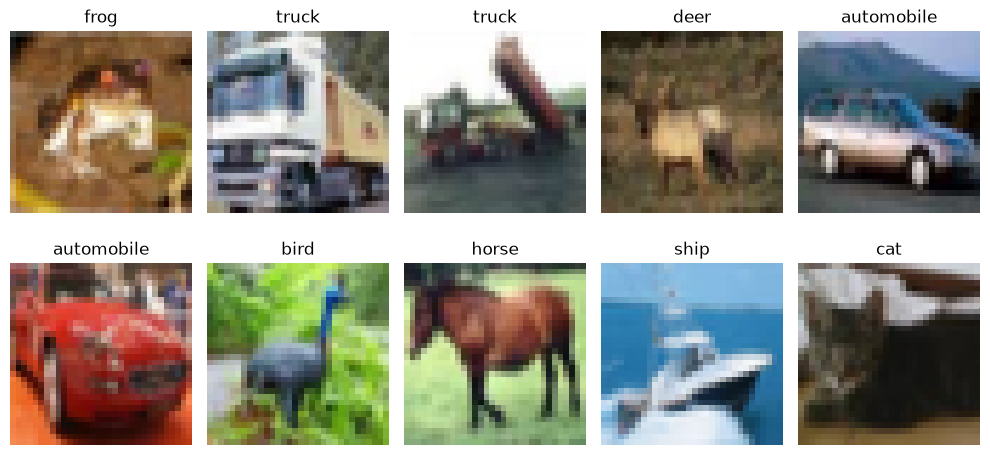

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\ashishjoshi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.2745 - loss: 1.9873 - val_accuracy: 0.3242 - val_loss: 1.8815
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3143 - loss: 1.8657 - val_accuracy: 0.3652 - val_loss: 1.7734
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3392 - loss: 1.8061 - val_accuracy: 0.3686 - val_loss: 1.7477
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3569 - loss: 1.7667 - val_accuracy: 0.3890 - val_loss: 1.7057
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3574 - loss: 1.7543 - val_accuracy: 0.3884 - val_loss: 1.7206
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.3711 - loss: 1.7275 - val_accuracy: 0.3760 - val_loss: 1.7142
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3714 - loss: 1.7217 - val_accuracy: 0.3888 - val_loss: 1.7035
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.3805 - loss: 1.7040 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4273 - loss: 1.6261
ANN Test Accuracy: 0.42730000615119934


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\ashishjoshi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4641 - loss: 1.5008 - val_accuracy: 0.3858 - val_loss: 1.8472
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.6038 - loss: 1.1330 - val_accuracy: 0.6374 - val_loss: 1.0290
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6678 - loss: 0.9473 - val_accuracy: 0.5150 - val_loss: 1.5794
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7088 - loss: 0.8344 - val_accuracy: 0.6278 - val_loss: 1.1032
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.7391 - loss: 0.7464 - val_accuracy: 0.6362 - val_loss: 1.1200
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.7691 - loss: 0.6598 - val_accuracy: 0.6904 - val_loss: 0.9135
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.7923 - loss: 0.5866 - val_accuracy: 0.7016 - val_loss: 0.9217
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.8114 - loss: 0.5323 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6993 - loss: 1.0026
CNN Test Accuracy: 0.6992999911308289


## 📈 Compare Learning Curves

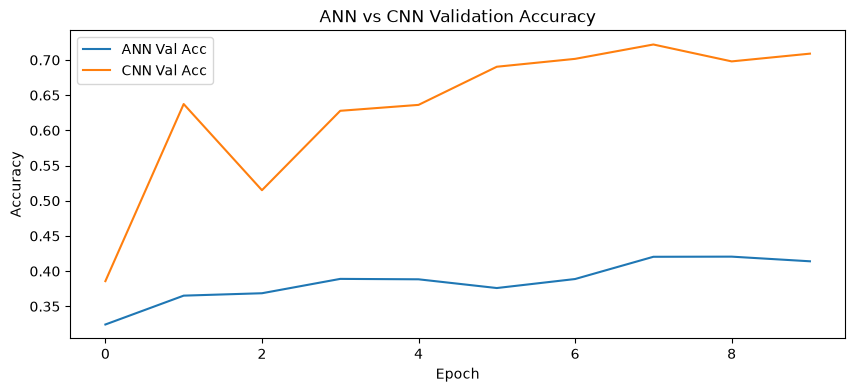

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4273
1,CNN,0.6993


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

### 1- Increase ANN layers and observe performance

In [12]:
ann_model_inc_layers = models.Sequential([
  layers.Dense(512, activation='relu', input_shape=(3072,)),
  layers.Dropout(0.3),

  layers.Dense(256, activation='relu'),
  layers.Dropout(0.3),

  layers.Dense(128, activation='relu'),
  layers.Dense(64, activation='relu'),

  layers.Dense(10, activation='softmax')
])

ann_model_inc_layers.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

ann_history = ann_model_inc_layers.fit(
  x_train_flat, y_train,
  epochs=10,
  validation_split=0.1,
  batch_size=64
)


C:\Users\ashishjoshi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.2283 - loss: 2.0621 - val_accuracy: 0.2986 - val_loss: 1.9004
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.2958 - loss: 1.9112 - val_accuracy: 0.3266 - val_loss: 1.8471
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3128 - loss: 1.8633 - val_accuracy: 0.3466 - val_loss: 1.8125
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3248 - loss: 1.8432 - val_accuracy: 0.3544 - val_loss: 1.8009
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3344 - loss: 1.8155 - val_accuracy: 0.3340 - val_loss: 1.8170
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3464 - loss: 1.7971 - val_accuracy: 0.3464 - val_loss: 1.8108
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3495 - loss: 1.7786 - val_accuracy: 0.3822 - val_loss: 1.7260
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3557 - loss: 1.7647 - 

In [13]:
ann_test_loss, ann_test_acc = ann_model_inc_layers.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy: (after increased layers)", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3850 - loss: 1.7017
ANN Test Accuracy: (after increased layers) 0.38499999046325684


### NOTE : Increasing number of layers in ANN does not significantly increase the accuracy
- Trying the ANN with Batch Normalization

In [14]:
ann_model_bn = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(10, activation='softmax')
])

ann_model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model_bn.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.3634 - loss: 1.8093 - val_accuracy: 0.3536 - val_loss: 1.8336
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4090 - loss: 1.6675 - val_accuracy: 0.4086 - val_loss: 1.6685
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4259 - loss: 1.6295 - val_accuracy: 0.4044 - val_loss: 1.7004
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4374 - loss: 1.5762 - val_accuracy: 0.4430 - val_loss: 1.5940
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4489 - loss: 1.5526 - val_accuracy: 0.4336 - val_loss: 1.6007
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4550 - loss: 1.5278 - val_accuracy: 0.4226 - val_loss: 1.6158
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4644 - loss: 1.5134 - val_accuracy: 0.4534 - val_loss: 1.5399
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4651 - loss: 1.5046 - 

In [15]:
ann_test_loss, ann_test_acc = ann_model_bn.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy: (after batch normalization)", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4565 - loss: 1.5237
ANN Test Accuracy: (after batch normalization) 0.45649999380111694


### 2- Change CNN filters from 32→64→128 
- This is already done in the previous CNN model

### 3- Increase epochs to 20

A - ANN

In [16]:
ann_model_inc_epochs = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')
])

ann_model_inc_epochs.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model_inc_epochs.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3622 - loss: 1.8092 - val_accuracy: 0.3454 - val_loss: 1.8691
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4141 - loss: 1.6536 - val_accuracy: 0.3680 - val_loss: 1.7596
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4285 - loss: 1.6055 - val_accuracy: 0.3432 - val_loss: 1.8626
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4367 - loss: 1.5892 - val_accuracy: 0.4300 - val_loss: 1.6143
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4416 - loss: 1.5676 - val_accuracy: 0.4470 - val_loss: 1.5768
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4510 - loss: 1.5372 - val_accuracy: 0.4224 - val_loss: 1.6306
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4592 - loss: 1.5203 - val_accuracy: 0.4342 - val_loss: 1.5728
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4669 - loss: 1.4966 - v

In [17]:
ann_test_loss, ann_test_acc = ann_model_inc_epochs.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy: (after increased epochs)", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4558 - loss: 1.5084
ANN Test Accuracy: (after increased epochs) 0.45579999685287476


B - CNN 

In [22]:
cnn_model_inc_epochs = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_inc_epochs.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model_inc_epochs.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

C:\Users\satya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.4667 - loss: 1.4822 - val_accuracy: 0.5146 - val_loss: 1.3531
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6115 - loss: 1.1056 - val_accuracy: 0.6446 - val_loss: 1.0199
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.6729 - loss: 0.9385 - val_accuracy: 0.6676 - val_loss: 0.9436
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7122 - loss: 0.8240 - val_accuracy: 0.7002 - val_loss: 0.8672
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7474 - loss: 0.7259 - val_accuracy: 0.7252 - val_loss: 0.8335
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7708 - loss: 0.6526 - val_accuracy: 0.7020 - val_loss: 0.9050
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7951 - loss: 0.5824 - val_accuracy: 0.7184 - val_loss: 0.8545
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.8162 - loss: 0.5203 - 

In [24]:
cnn_test_loss, cnn_test_acc = cnn_model_inc_epochs.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:(after increased epochs)", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7219 - loss: 1.3245
CNN Test Accuracy:(after increased epochs) 0.7218999862670898


### Comparison of the learning curves of the two models after optimizations

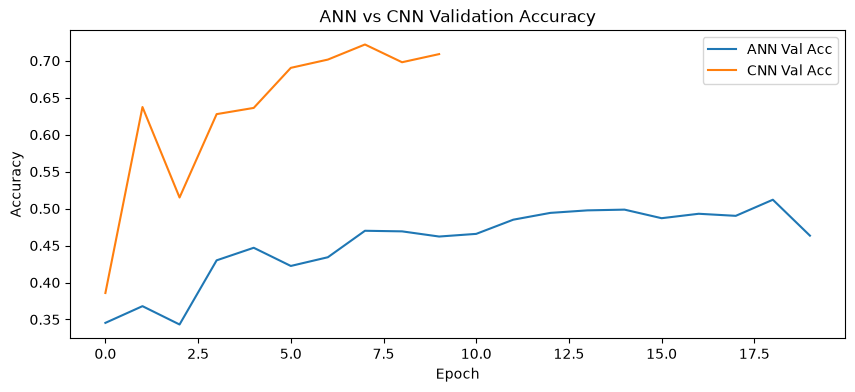

In [18]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

In [19]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4558
1,CNN,0.6993


### Note: ANN improved with increased epochs but CNN did not have much effect of the change

### 4 - Add **EarlyStopping**
### 5 - Add **data augmentation training**

# 🚀 Training Strategy Upgrade: Data Augmentation and Early Stopping
This strategy improves generalization by generating transformed images.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# CNN with Data Augmentation
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

# Evaluate on test set
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=1
)

C:\Users\ashishjoshi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.4343 - loss: 1.6255 - val_accuracy: 0.5176 - val_loss: 1.3998
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5361 - loss: 1.3037 - val_accuracy: 0.5816 - val_loss: 1.1698
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.5745 - loss: 1.2009 - val_accuracy: 0.6162 - val_loss: 1.1065
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.5935 - loss: 1.1479 - val_accuracy: 0.5094 - val_loss: 1.4164
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6108 - loss: 1.0999 - val_accuracy: 0.5992 - val_loss: 1.1996
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6272 - loss: 1.0562 - val_accuracy: 0.6586 - val_loss: 0.9809
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6395 - loss: 1.0245 - val_accuracy: 0.6248 - val_loss: 1.1172
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6500 - loss: 0.9967 - 

In [21]:
print("CNN Test Accuracy:(after increased epochs)", aug_test_acc)

CNN Test Accuracy:(after increased epochs) 0.7023000121116638


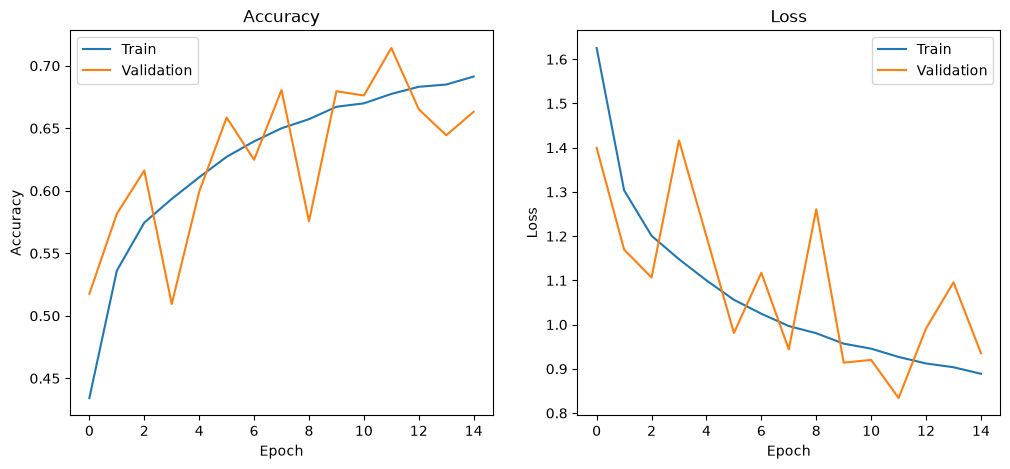

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(aug_history.history['accuracy'], label='Train')
plt.plot(aug_history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(aug_history.history['loss'], label='Train')
plt.plot(aug_history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**